In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:


file_path = "/content/Movies.csv"   # Change dataset path

# Auto detect file type
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Only CSV and Excel files are supported")

print("\nDataset Loaded Successfully")
print("Shape :", df.shape)


Dataset Loaded Successfully
Shape : (10000, 8)


In [ ]:

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed : {duplicates}")


Duplicates Removed : 0


In [ ]:

for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing Values Handled")


Missing Values Handled


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns

initial_rows = len(df)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

final_rows = len(df)

print(f"\nRows Removed By IQR : {initial_rows - final_rows}")


Rows Removed By IQR : 1935


In [ ]:


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    df.drop(columns=constant_cols, inplace=True)

print("\nConstant Columns Removed :", constant_cols)


Constant Columns Removed : []


In [ ]:


df.reset_index(drop=True, inplace=True)

In [ ]:


print("\nFinal Shape :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape : (8065, 8)

Missing Values After Cleaning:
Unnamed: 0      0
id              0
title           0
release_date    0
overview        0
popularity      0
vote_average    0
vote_count      0
dtype: int64



Cleaned Dataset Saved Successfully


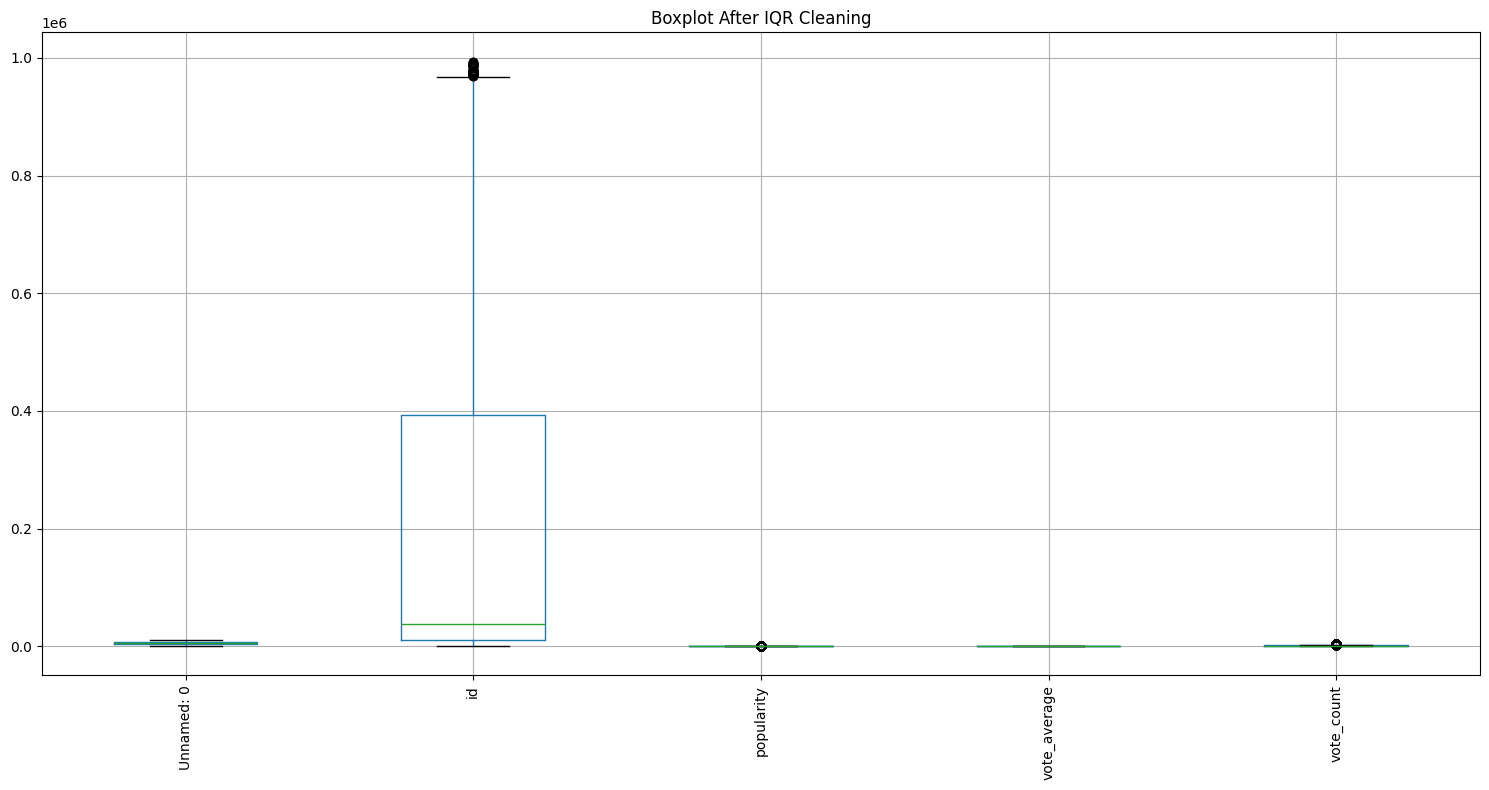

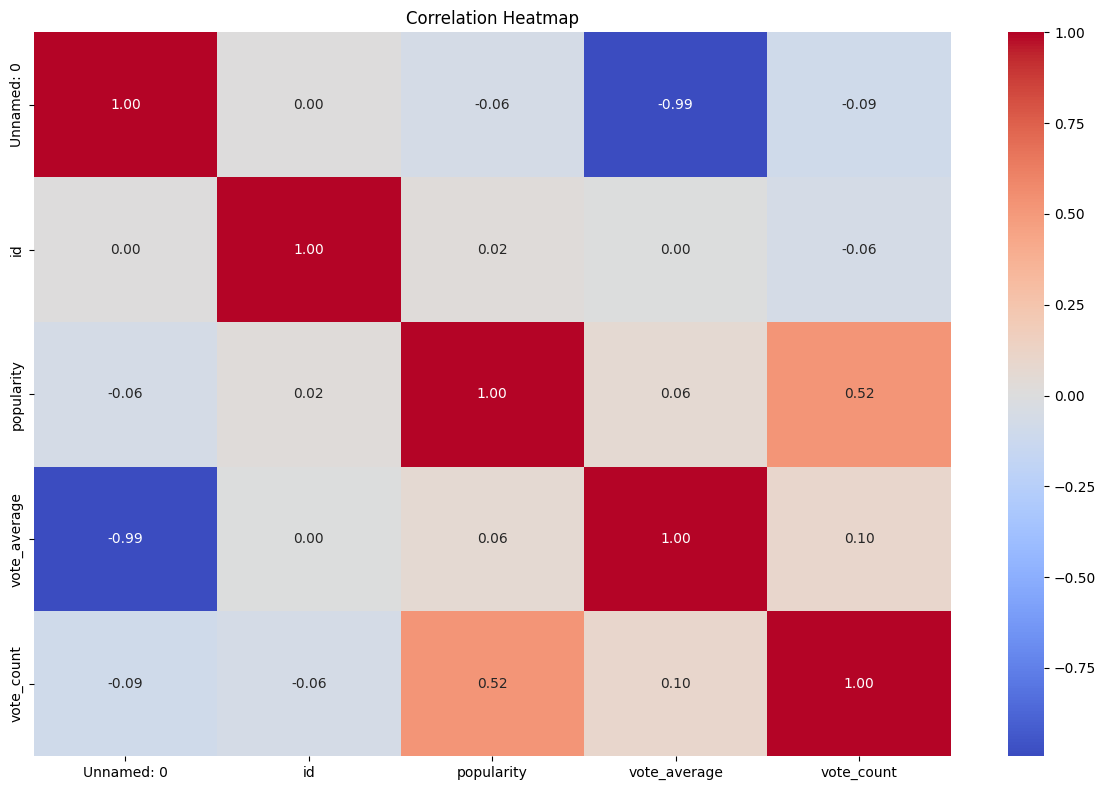


Data Cleaning Completed Successfully


In [ ]:


df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

numeric_cols = [col for col in numeric_cols if col in df.columns]


if len(numeric_cols) > 0:

    plt.figure(figsize=(15,8))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After IQR Cleaning")
    plt.tight_layout()
    plt.show()



if len(numeric_cols) > 1:

    plt.figure(figsize=(12,8))
    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

print("\nData Cleaning Completed Successfully")

In [ ]:
df = pd.read_csv("/content/cleaned_dataset.csv")
df

,Unnamed: 0,id,title,release_date,overview,popularity,vote_average,vote_count
0,21,14537,Harakiri,1962-09-15,Down-on-his-luck veteran Tsugumo Hanshirō ente...,4.6655,8.400,1169
1,25,40096,A Dog's Will,2000-09-15,The lively João Grilo and the sly Chicó are po...,2.2842,8.400,1205
2,26,667257,Impossible Things,2021-06-17,"After the death of her abusive husband, Matild...",1.5420,8.421,419
3,30,696374,Gabriel's Inferno,2020-05-29,An intriguing and sinful exploration of seduct...,2.2706,8.400,2444
4,31,255709,Hope,2013-10-02,After 8-year-old So-won narrowly survives a br...,6.5100,8.395,824
...,...,...,...,...,...,...,...,...
8060,9995,447665,Kickboxer: Retaliation,2018-01-26,"One year after the events of ""Kickboxer: Venge...",3.5296,5.439,319
8061,9996,18162,Land of the Lost,2009-06-05,"On his latest expedition, has-been scientist D...",3.2432,5.400,1405
8062,9997,50217,From Prada to Nada,2011-01-28,Two spoiled Beverly Hills sisters who have bee...,1.3939,5.400,330
8063,9998,38317,Zookeeper,2011-07-06,Kindhearted Griffin Keyes is one of the best-l...,2.9887,5.438,1756


In [ ]:
df['is_high_rated'] = (df['vote_average'] > 7.0).astype(int)
X = df[['popularity', 'vote_count']]
y = df['is_high_rated']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.615623062616243
              precision    recall  f1-score   support

           0       0.68      0.82      0.74      1101
           1       0.31      0.17      0.22       512

    accuracy                           0.62      1613
   macro avg       0.50      0.50      0.48      1613
weighted avg       0.56      0.62      0.58      1613

